<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test1/nn_test1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

In [2]:
# imports
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 as transforms


# config
train_batch_size = 64
test_batch_size = 64
learning_rate = 1e-3
epochs = 25


# training and test data
image_transform = transforms.Compose([
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True)
])

training_data = datasets.MNIST(
    root = "data",
    train = True,
    download = True,
    transform = image_transform
)

test_data = datasets.MNIST(
    root = "data",
    train = False,
    download = True,
    transform = image_transform
)

training_loader = DataLoader(training_data, batch_size=train_batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=test_batch_size, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 57.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.75MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.64MB/s]


### Data Examples

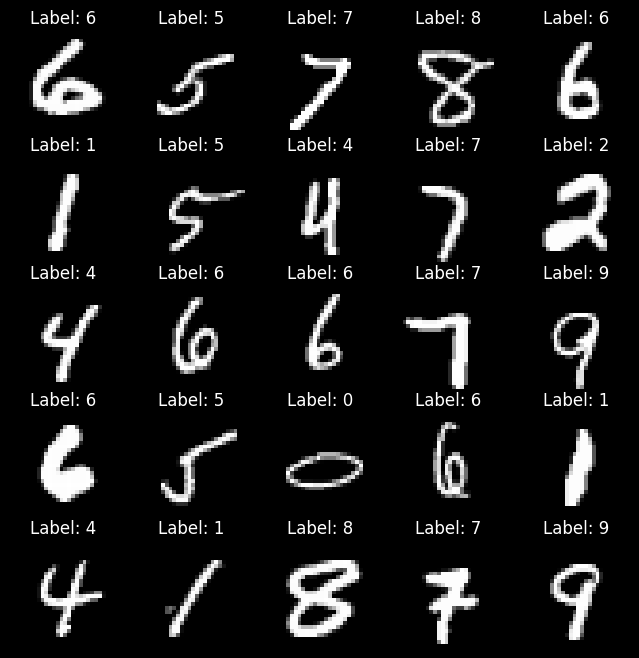

In [3]:
# examples
plt.style.use('dark_background')
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    rand_index = torch.randint(0, len(training_data)-25, (1,)).item()
    image, label = training_data[rand_index+i]
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

### Model

In [4]:
# model
class ConvNeuralNetwork(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.convolution = nn.Sequential(
        nn.Conv2d(1, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.convolution(x)
    output = self.classifier(x) # logit

    return output

  def predict(self, x, probabilities=False):
    self.eval()
    with torch.no_grad():
      output = self(x)

    probs_tensor = torch.softmax(output, dim=1)
    if probabilities:
      return probs_tensor
    else:
      pred = torch.argmax(probs_tensor)
      return pred


model = ConvNeuralNetwork()



### Training and Testing

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


def train(dataloader, model, loss_fn, optimizer):
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    output = model(X)
    loss = loss_fn(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{len(dataloader.dataset):>5d}]")


def evaluate(dataloader, model, loss_fn, dataset_name="Test"):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
      for X, y in dataloader:
        output = model(X)
        total_loss += loss_fn(output, y).item()
        pred = output.argmax(1)
        correct += (pred == y).type(torch.float).sum().item()
    total_loss /= len(dataloader)
    correct /= len(dataloader.dataset)

    print(f"{dataset_name} \n Avg loss: {total_loss:>8f}, Accuracy: {(100*correct):>0.1f}% \n")
    return correct


print("Initial Model Performance:")
evaluate(training_loader, model, loss_fn, dataset_name="Train")
evaluate(test_loader, model, loss_fn, dataset_name="Test")

for epoch in range(epochs):
  print(f"Eppoch {epoch+1}/{epochs}")
  train(training_loader, model, loss_fn, optimizer)
  evaluate(training_loader, model, loss_fn, dataset_name="Train")
  evaluate(test_loader, model, loss_fn, dataset_name="Test")

print("Training and testing completed")


# total parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params}')

# save model
torch.save(model.state_dict(), 'model_weights.pth')
torch.save(model, 'model.pth')


Initial Model Performance:
Train 
 Avg loss: 2.304835, Accuracy: 8.1% 

Test 
 Avg loss: 2.305118, Accuracy: 8.5% 

Eppoch 1/25
loss: 2.292613  [    0/60000]
loss: 2.302097  [ 6400/60000]
loss: 2.287416  [12800/60000]
loss: 2.278678  [19200/60000]
loss: 2.281031  [25600/60000]
loss: 2.276510  [32000/60000]
loss: 2.261574  [38400/60000]
loss: 2.250507  [44800/60000]
loss: 2.247821  [51200/60000]
loss: 2.219969  [57600/60000]
Train 
 Avg loss: 2.230041, Accuracy: 56.5% 

Test 
 Avg loss: 2.228668, Accuracy: 58.0% 

Eppoch 2/25
loss: 2.221782  [    0/60000]
loss: 2.237677  [ 6400/60000]
loss: 2.205415  [12800/60000]
loss: 2.163613  [19200/60000]
loss: 2.152290  [25600/60000]
loss: 2.166666  [32000/60000]
loss: 2.120898  [38400/60000]
loss: 2.082165  [44800/60000]
loss: 2.050641  [51200/60000]
loss: 1.935284  [57600/60000]
Train 
 Avg loss: 1.974848, Accuracy: 60.7% 

Test 
 Avg loss: 1.968982, Accuracy: 61.8% 

Eppoch 3/25
loss: 1.989986  [    0/60000]
loss: 1.914930  [ 6400/60000]
loss: 

### Prediction Example

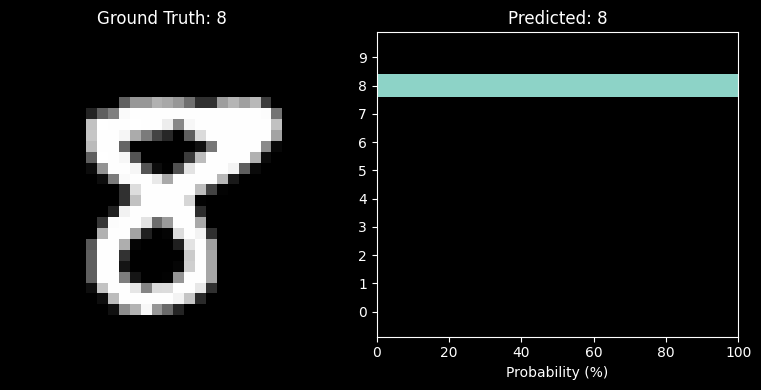

In [24]:
plt.style.use('dark_background')
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
rand_index = torch.randint(0, len(training_data), (1,)).item()
image, label = training_data[rand_index]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Ground Truth: {label}")
plt.axis("off")

pred = model.predict(image.unsqueeze(0))
probabilities = model.predict(image.unsqueeze(0), probabilities=True)

plt.subplot(1, 2, 2)
class_labels = [str(i) for i in range(10)]
plt.barh(class_labels, probabilities.squeeze().numpy() * 100)
plt.title(f"Predicted: {pred.item()}")
plt.xlabel("Probability (%)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()